<a href="https://colab.research.google.com/github/tishhapatel/Advance-DataScience-and-ML/blob/main/NLP_practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install missing packages
import subprocess, sys

def install(pkg):
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg, "-q",
         "--break-system-packages"],
        stderr=subprocess.DEVNULL
    )

for pkg in ["pandas", "numpy", "matplotlib",
            "seaborn", "nltk", "wordcloud"]:
    install(pkg)

# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings("ignore")

# Download NLTK data
for r in ["punkt", "punkt_tab", "stopwords",
          "wordnet", "omw-1.4"]:
    nltk.download(r, quiet=True)

print("✅ All libraries ready!")

✅ All libraries ready!


load dataset

In [3]:
# Load spam.csv — only columns 0 and 1 are needed
df = pd.read_csv(
    "spam.csv",          # change path if needed
    encoding="latin-1",  # handles special SMS characters
    usecols=[0, 1],       # skip the 3 empty extra columns
    names=["label", "message"],  # rename v1→label, v2→message
    header=0             # row 0 is original header, skip it
)

print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())

Shape  : (5572, 2)
Columns: ['label', 'message']

First 5 rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


Explore Dataset

In [4]:
# --- 2a. Basic info ---
print("Data types & null counts:")
df.info()

# --- 2b. Missing values ---
print("\nMissing values:")
print(df.isnull().sum())

# --- 2c. Class distribution ---
dist = df["label"].value_counts()
print("\nClass Distribution:")
print(dist)
print(f"\nHam  : {dist['ham']:,}  ({dist['ham']/len(df)*100:.2f}%)")
print(f"Spam : {dist['spam']:,}  ({dist['spam']/len(df)*100:.2f}%)")

# --- 2d. Sample messages ---
print("\nSample HAM :", df[df["label"]=="ham"]["message"].iloc[0])
print("Sample SPAM:", df[df["label"]=="spam"]["message"].iloc[0])

Data types & null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Missing values:
label      0
message    0
dtype: int64

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Ham  : 4,825  (86.59%)
Spam : 747  (13.41%)

Sample HAM : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Sample SPAM: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


feature Engineering

In [5]:
# Add length features
df["msg_length"] = df["message"].apply(len)
df["word_count"] = df["message"].apply(lambda x: len(x.split()))

# Summary stats by class
print("Descriptive statistics by label:\n")
print(
    df.groupby("label")[["msg_length", "word_count"]]
      .describe()
      .round(2)
)

Descriptive statistics by label:

      msg_length                                                  word_count  \
           count    mean    std   min    25%    50%    75%    max      count   
label                                                                          
ham       4825.0   71.02  58.02   2.0   33.0   52.0   92.0  910.0     4825.0   
spam       747.0  138.87  29.18  13.0  132.5  149.0  157.0  224.0      747.0   

                                                   
        mean    std  min   25%   50%   75%    max  
label                                              
ham    14.20  11.42  1.0   7.0  11.0  19.0  171.0  
spam   23.85   5.81  2.0  22.0  25.0  28.0   35.0  


Text Preprocessing

In [6]:
STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    """Full NLP cleaning pipeline."""
    # 1. Lowercase
    text = text.lower()

    # 2. Remove punctuation, numbers, special chars
    text = re.sub(r"[^a-z\s]", "", text)

    # 3. Tokenize — split into word list
    tokens = word_tokenize(text)

    # 4. Remove stopwords and short tokens (≤2 chars)
    tokens = [t for t in tokens
              if t not in STOP_WORDS and len(t) > 2]

    # 5. Lemmatize each token
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

df["cleaned"] = df["message"].apply(preprocess)

# Show before → after examples
for i in [0, 2, 9]:
    row = df.iloc[i]
    print(f"[{row['label'].upper()}]")
    print(f"  Original : {row['message'][:70]}...")
    print(f"  Cleaned  : {row['cleaned'][:70]}")
    print()

[HAM]
  Original : Go until jurong point, crazy.. Available only in bugis n great world l...
  Cleaned  : jurong point crazy available bugis great world buffet cine got amore w

[SPAM]
  Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Te...
  Cleaned  : free entry wkly comp win cup final tkts may text receive entry questio

[SPAM]
  Original : Had your mobile 11 months or more? U R entitled to Update to the lates...
  Cleaned  : mobile month entitled update latest colour mobile camera free call mob



word Frequency

In [7]:
# Join all words per class into one big string
spam_corpus = " ".join(df[df["label"]=="spam"]["cleaned"])
ham_corpus  = " ".join(df[df["label"]=="ham"]["cleaned"])

# Count word frequencies
spam_freq = Counter(spam_corpus.split())
ham_freq  = Counter(ham_corpus.split())

# Print top 15 for each
print(f"{'Word':<15} {'SPAM':>6}    {'Word':<15} {'HAM':>6}")
print("-"*50)
for (sw, sc), (hw, hc) in zip(
        spam_freq.most_common(15),
        ham_freq.most_common(15)):
    print(f"{sw:<15} {sc:>6}    {hw:<15} {hc:>6}")

Word              SPAM    Word               HAM
--------------------------------------------------
call               362    get                318
free               219    ltgt               276
txt                151    dont               268
text               138    got                244
mobile             136    come               242
stop               116    know               241
claim              115    call               241
reply              103    ill                240
prize               94    like               232
get                 83    good               223
tone                73    day                219
service             72    time               214
nokia               69    love               193
new                 69    want               183
send                67    need               171


Visualization

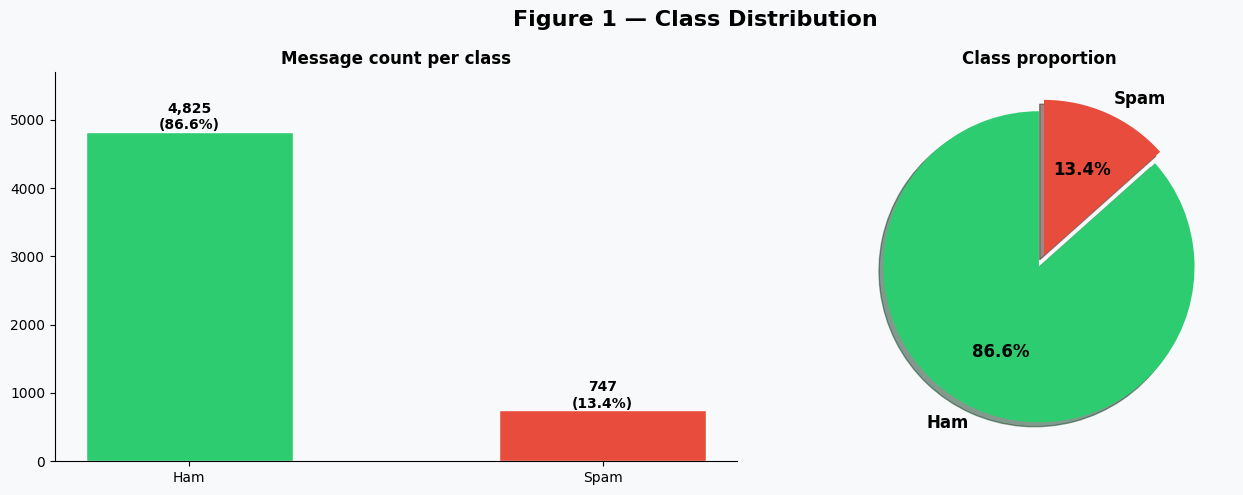

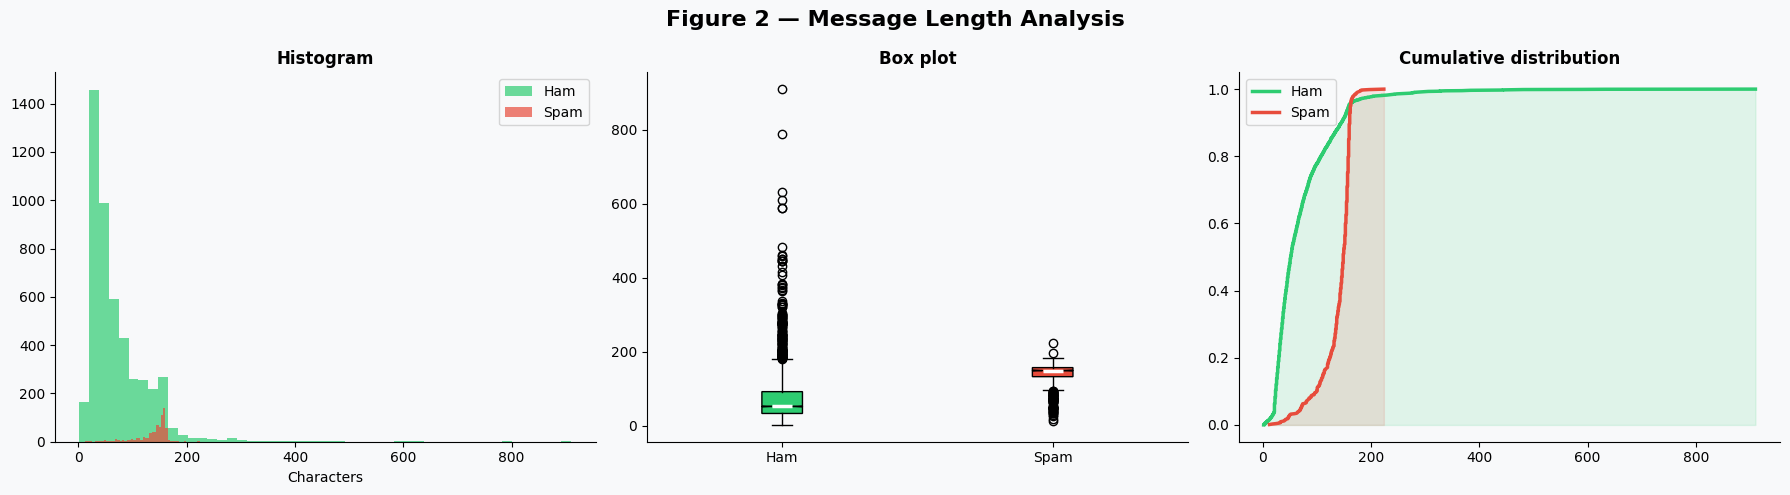

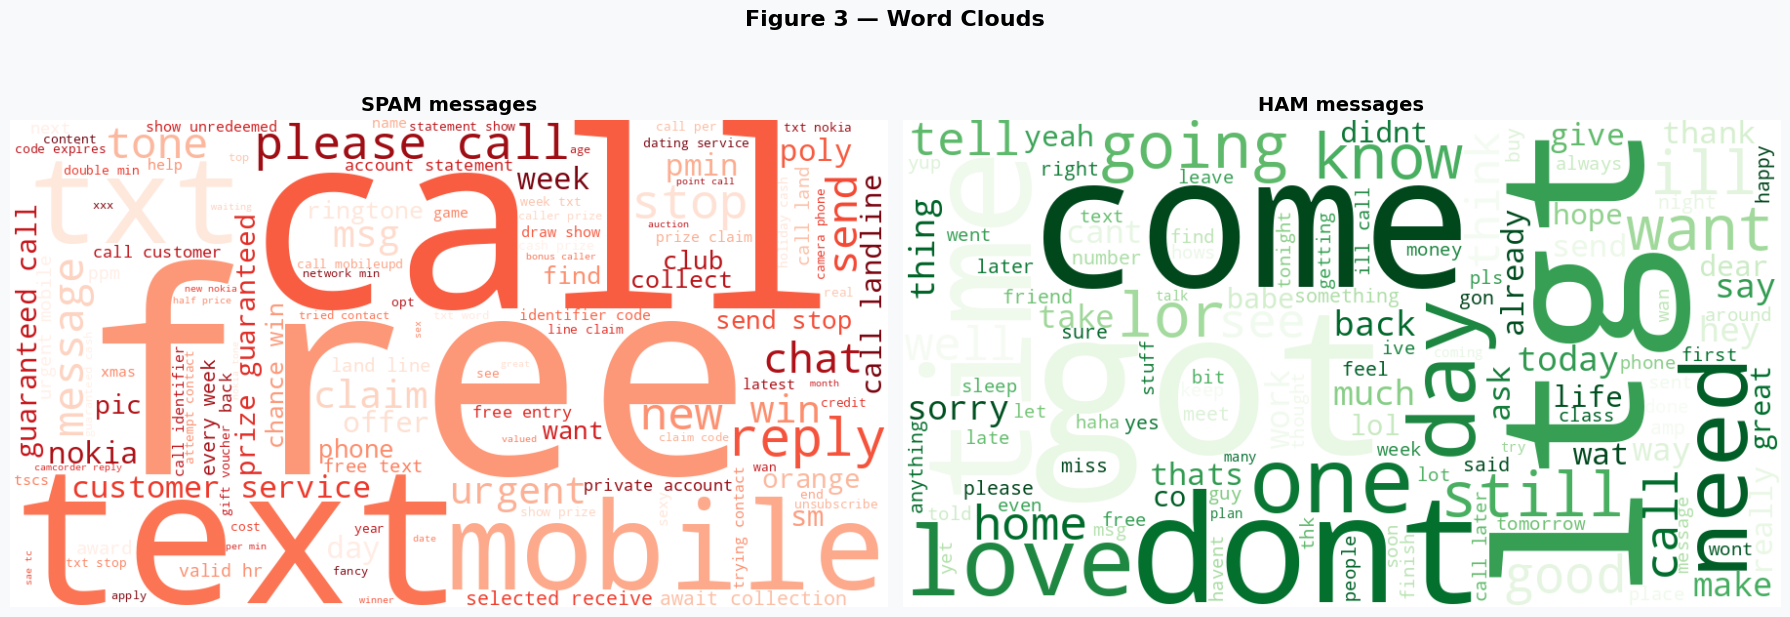

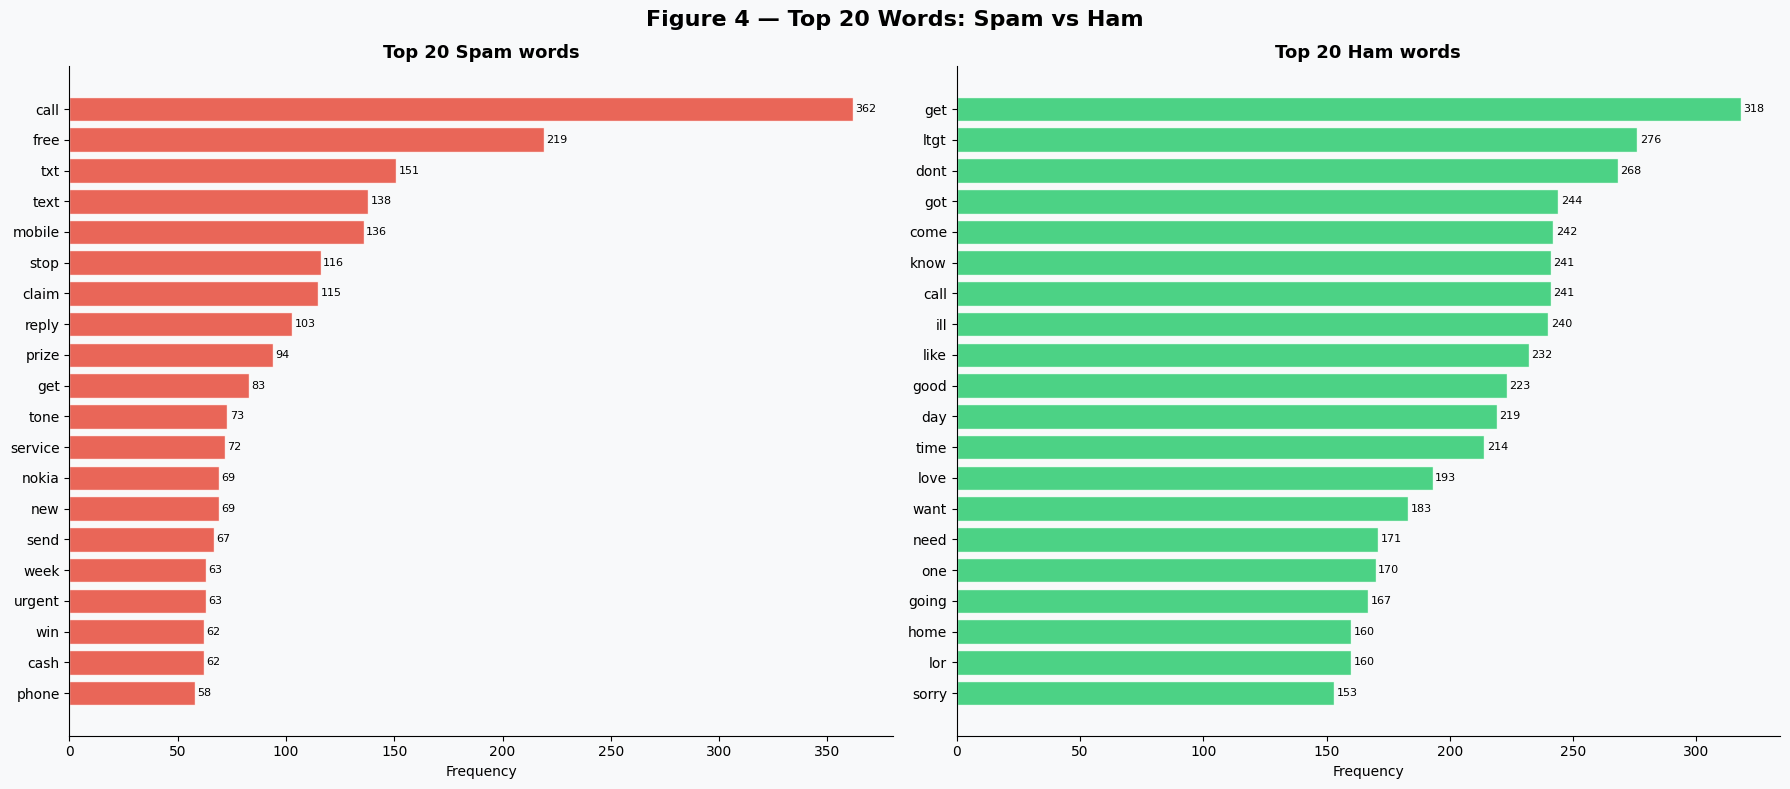

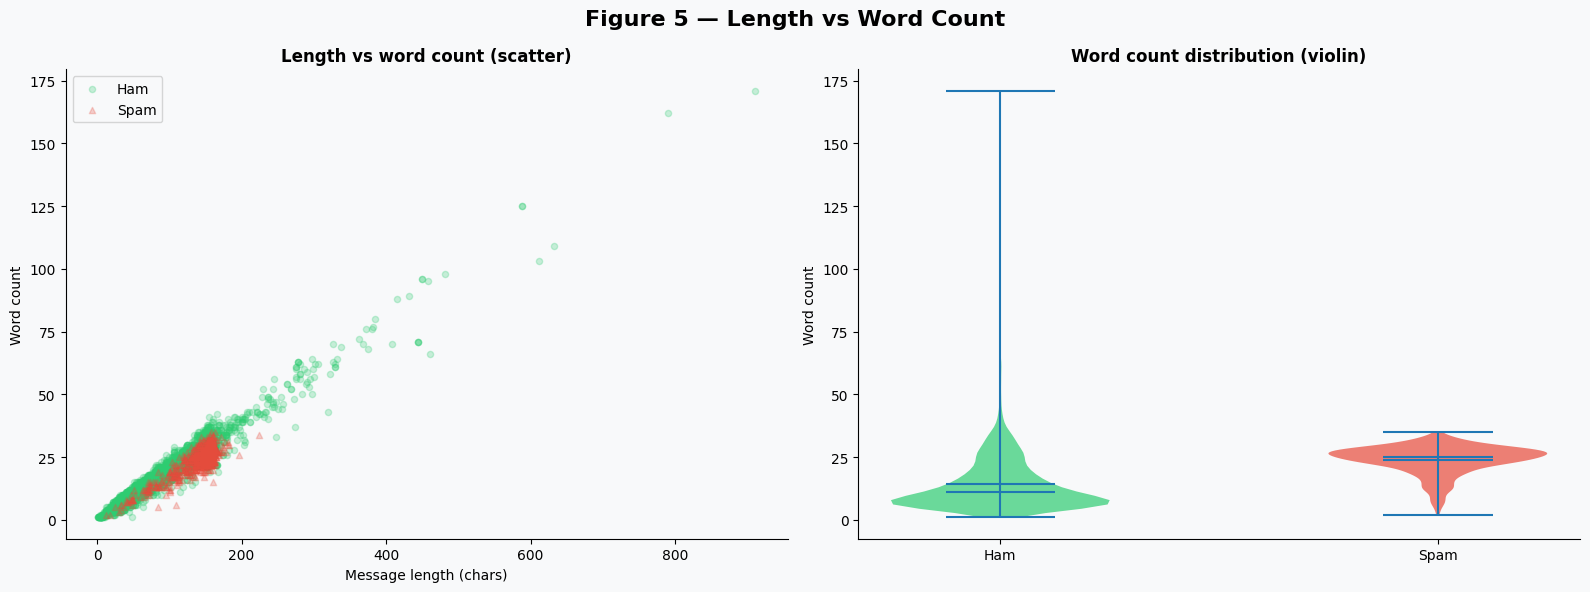

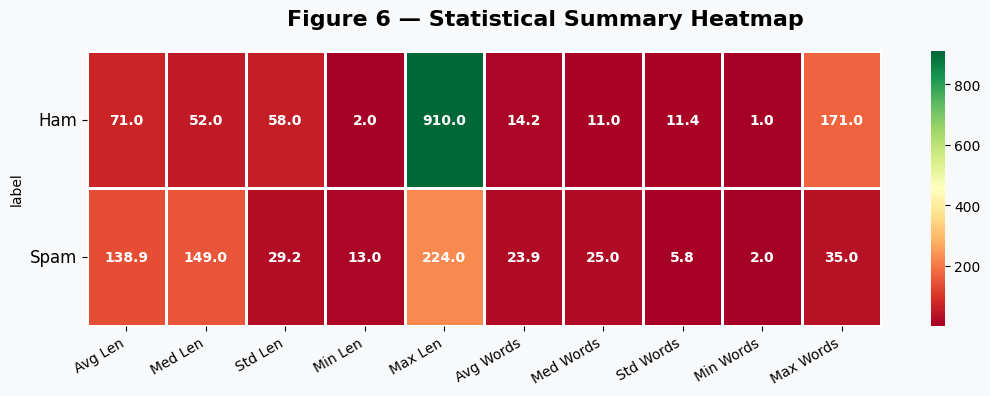

In [8]:
# Global color settings
SPAM_C = "#E74C3C"   # red
HAM_C  = "#2ECC71"   # green
BG     = "#F8F9FA"
ACC    = "#2C3E50"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans"
})

# ── Figure 1: Class distribution ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 1 — Class Distribution",
             fontsize=16, fontweight="bold")

counts = df["label"].value_counts()
bars = axes[0].bar(["Ham", "Spam"], counts.values,
                   color=[HAM_C, SPAM_C], width=0.5, edgecolor="white")
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+40,
                 f"{val:,}\n({val/len(df)*100:.1f}%)",
                 ha="center", fontweight="bold")
axes[0].set_title("Message count per class", fontweight="bold")
axes[0].set_ylim(0, max(counts.values) * 1.18)

axes[1].pie(counts.values, labels=["Ham", "Spam"],
           colors=[HAM_C, SPAM_C], autopct="%1.1f%%",
           startangle=90, explode=(0, 0.08), shadow=True,
           textprops={"fontsize": 12, "fontweight": "bold"})
axes[1].set_title("Class proportion", fontweight="bold")

plt.tight_layout()
plt.savefig("fig1_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2: Message length analysis ─────────────────
ham_len  = df[df["label"]=="ham"]["msg_length"]
spam_len = df[df["label"]=="spam"]["msg_length"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Figure 2 — Message Length Analysis",
             fontsize=16, fontweight="bold")

axes[0].hist(ham_len,  bins=50, alpha=0.7, color=HAM_C,  label="Ham")
axes[0].hist(spam_len, bins=50, alpha=0.7, color=SPAM_C, label="Spam")
axes[0].set_title("Histogram", fontweight="bold")
axes[0].set_xlabel("Characters")
axes[0].legend()

bp = axes[1].boxplot([ham_len, spam_len], labels=["Ham", "Spam"],
                    patch_artist=True, notch=True,
                    medianprops={"color": "white", "linewidth": 2.5})
bp["boxes"][0].set_facecolor(HAM_C)
bp["boxes"][1].set_facecolor(SPAM_C)
axes[1].set_title("Box plot", fontweight="bold")

for data, color, lbl in [(ham_len, HAM_C, "Ham"),
                          (spam_len, SPAM_C, "Spam")]:
    sd  = np.sort(data)
    cdf = np.arange(1, len(sd)+1) / len(sd)
    axes[2].plot(sd, cdf, color=color, linewidth=2.5, label=lbl)
    axes[2].fill_between(sd, cdf, alpha=0.12, color=color)
axes[2].set_title("Cumulative distribution", fontweight="bold")
axes[2].legend()

plt.tight_layout()
plt.savefig("fig2_message_length.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 3: Word clouds ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Figure 3 — Word Clouds", fontsize=16, fontweight="bold")

for ax, corpus, cmap, title in [
    (axes[0], spam_corpus, "Reds",   "SPAM messages"),
    (axes[1], ham_corpus,  "Greens", "HAM messages")
]:
    wc = WordCloud(width=900, height=500,
                   background_color="white", colormap=cmap,
                   max_words=120, min_font_size=8).generate(corpus)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontweight="bold", fontsize=14)

plt.tight_layout()
plt.savefig("fig3_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 4: Top 20 words bar chart ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Figure 4 — Top 20 Words: Spam vs Ham",
             fontsize=16, fontweight="bold")

def plot_top_words(ax, freq, color, title, n=20):
    top = freq.most_common(n)
    words, counts = zip(*top)
    words, counts = list(reversed(words)), list(reversed(counts))
    bars = ax.barh(words, counts, color=color, alpha=0.85, edgecolor="white")
    for bar, c in zip(bars, counts):
        ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                str(c), va="center", fontsize=8)
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.set_xlabel("Frequency")

plot_top_words(axes[0], spam_freq, SPAM_C, "Top 20 Spam words")
plot_top_words(axes[1], ham_freq,  HAM_C,  "Top 20 Ham words")

plt.tight_layout()
plt.savefig("fig4_top_words.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 5: Scatter + violin ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Figure 5 — Length vs Word Count",
             fontsize=16, fontweight="bold")

for lbl, color, mk in [("ham", HAM_C, "o"), ("spam", SPAM_C, "^")]:
    sub = df[df["label"]==lbl]
    axes[0].scatter(sub["msg_length"], sub["word_count"],
                    alpha=0.25, s=20, color=color,
                    label=lbl.capitalize(), marker=mk)
axes[0].set_title("Length vs word count (scatter)", fontweight="bold")
axes[0].set_xlabel("Message length (chars)")
axes[0].set_ylabel("Word count")
axes[0].legend()

parts = axes[1].violinplot(
    [df[df["label"]=="ham"]["word_count"].values,
     df[df["label"]=="spam"]["word_count"].values],
    showmeans=True, showmedians=True)
for pc, color in zip(parts["bodies"], [HAM_C, SPAM_C]):
    pc.set_facecolor(color); pc.set_alpha(0.7)
axes[1].set_xticks([1, 2]); axes[1].set_xticklabels(["Ham", "Spam"])
axes[1].set_title("Word count distribution (violin)", fontweight="bold")
axes[1].set_ylabel("Word count")

plt.tight_layout()
plt.savefig("fig5_scatter_violin.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 6: Heatmap ──────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
fig.suptitle("Figure 6 — Statistical Summary Heatmap",
             fontsize=16, fontweight="bold")

summary = (
    df.groupby("label")[["msg_length", "word_count"]]
      .agg(["mean", "median", "std", "min", "max"])
      .round(1)
)
summary.columns = ["Avg Len", "Med Len", "Std Len",
                   "Min Len", "Max Len",
                   "Avg Words", "Med Words", "Std Words",
                   "Min Words", "Max Words"]

sns.heatmap(summary, annot=True, fmt=".1f", cmap="RdYlGn",
            linewidths=1, linecolor="white",
            annot_kws={"size": 10, "weight": "bold"}, ax=ax)
ax.set_yticklabels(["Ham", "Spam"], rotation=0, fontsize=12)
ax.set_xticklabels(summary.columns, rotation=30, ha="right")

plt.tight_layout()
plt.savefig("fig6_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Key Findings

In [9]:
ham_df  = df[df["label"]=="ham"]
spam_df = df[df["label"]=="spam"]

print(f"""
DATASET
  Total   : {len(df):,} messages
  Ham     : {len(ham_df):,}  ({len(ham_df)/len(df)*100:.1f}%)
  Spam    : {len(spam_df):,}   ({len(spam_df)/len(df)*100:.1f}%)

MESSAGE LENGTH
  Ham  avg : {ham_df['msg_length'].mean():.0f} chars
  Spam avg : {spam_df['msg_length'].mean():.0f} chars
  → Spam is {spam_df['msg_length'].mean()/ham_df['msg_length'].mean():.1f}x longer

WORD COUNT
  Ham  avg : {ham_df['word_count'].mean():.1f} words
  Spam avg : {spam_df['word_count'].mean():.1f} words

TOP SPAM KEYWORDS
  {', '.join([w for w,_ in spam_freq.most_common(8)])}

TOP HAM KEYWORDS
  {', '.join([w for w,_ in ham_freq.most_common(8)])}

CONCLUSION
  1. Spam messages are significantly longer in both characters and words.
  2. Spam uses promotional/urgency language: free, call, win, prize, claim.
  3. Ham uses conversational language: got, ok, come, know, want, good.
  4. Message length alone is a strong discriminating feature.
  5. These patterns support ML classification via Naive Bayes or SVM.
""")


DATASET
  Total   : 5,572 messages
  Ham     : 4,825  (86.6%)
  Spam    : 747   (13.4%)

MESSAGE LENGTH
  Ham  avg : 71 chars
  Spam avg : 139 chars
  → Spam is 2.0x longer

WORD COUNT
  Ham  avg : 14.2 words
  Spam avg : 23.9 words

TOP SPAM KEYWORDS
  call, free, txt, text, mobile, stop, claim, reply

TOP HAM KEYWORDS
  get, ltgt, dont, got, come, know, call, ill

CONCLUSION
  1. Spam messages are significantly longer in both characters and words.
  2. Spam uses promotional/urgency language: free, call, win, prize, claim.
  3. Ham uses conversational language: got, ok, come, know, want, good.
  4. Message length alone is a strong discriminating feature.
  5. These patterns support ML classification via Naive Bayes or SVM.

